# 03 · Gold — Indicadores, escenarios y respuestas a las preguntas de negocio
Cada respuesta indica la **naturaleza del dato**: observado, estimado, proyección oficial, cálculo del pipeline,
escenario propio o inferencia propia (retroalimentación del profesor).

In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 200); pd.set_option('display.max_colwidth', 80)
GOLD, SILVER, CTL = RAIZ/'data'/'gold', RAIZ/'data'/'silver', RAIZ/'data'/'ctl'
from src.transformation.gold import leer
h, p, fl = leer('fact_indicador_historico'), leer('fact_indicador_proyeccion'), leer('fact_fuerza_laboral_escenario')
F = RAIZ/'docs'/'figuras'

## Tablero OKR

In [2]:
o = pd.read_parquet(GOLD/'kpi_okr.parquet'); o[['kr','kpi','valor','meta','cumple','interpretacion']]

,kr,kpi,valor,meta,cumple,interpretacion
0,KR1.1,Serie demográfica y laboral integrada: nacional 1970-2025 y 17 si-do 2000-2025,96.2 % / 97.0 %,completitud ≥ 95 % nacional y ≥ 90 % regional,True,celdas con dato / esperadas (Sejong desde 2012; EAPS Sejong desde 2017)
1,KR1.2,"Indicadores de natalidad y envejecimiento con fórmula única, validados contr...",6 · 0.37 %,6 indicadores · diferencia ≤ 1 %,True,"dependencia (juvenil, vejez, total), índice de envejecimiento, % 15-64, % 65..."
2,KR1.3,Brecha de Corea frente a la OCDE cuantificada,8 + Corea,≥ 5 países de comparación,True,"TFR Corea 0,80 vs OCDE 1,48: 46 % por debajo"
3,KR2.1,Escenarios oficiales KOSTAT integrados sin modificar y separados del histórico,29 escenarios · 100 %,100 % de registros con escenario y edición,True,2023-2072 nacional y 2023-2052 provincial; el histórico no contiene proyecci...
4,KR2.2,"Escenarios propios de fuerza laboral con supuestos explícitos, escala ajusta...",4 · sin ajuste +1.51 % · 8 variantes,4 supuestos · diferencia sin ajuste ≤ ±5 % · sensibilidad publicada,True,A constante · B tendencia 2015-2025 · C convergencia OCDE · D cierre 50 % br...
5,KR2.3,Pérdida de población en edad de trabajar y de fuerza laboral a 2050 cuantifi...,"15-64: -36,4 % a -27,4 %",rango en todos los escenarios,True,"fuerza laboral potencial (medio): A -11,7 %; B -4,9 %; C -11,8 %; D -5,7 %"
6,KR3.1,Riesgo demográfico-laboral medido para todas las regiones,17 de 17 · 6 en riesgo alto,17 de 17 si-do,True,"índice de 6 componentes (inferencia propia, ponderación igual); top 5 en los..."
7,KR3.2,"Palancas de política cuantificadas (natalidad, migración, participación, bre...",4 de 4,4 de 4 palancas,True,"efecto a 2050: fecundidad alta +1,4 pp en Pob 15-64 · migración alta vs cero..."
8,KR3.3,Tablero de Power BI que responde las 10 preguntas de negocio,10 de 10 · 8 páginas,10 de 10 preguntas,True,"../powerbi/ETL_Corea_Grupo6.pbix (portada, natalidad, envejecimiento, fuerza..."
9,KR4.1,Registros válidos tras las reglas de calidad,99.96 %,≥ 98.0 %,True,registros que pasan todas las reglas / evaluados


## P1 · ¿Cómo han evolucionado la natalidad y la fecundidad? *(observado)*

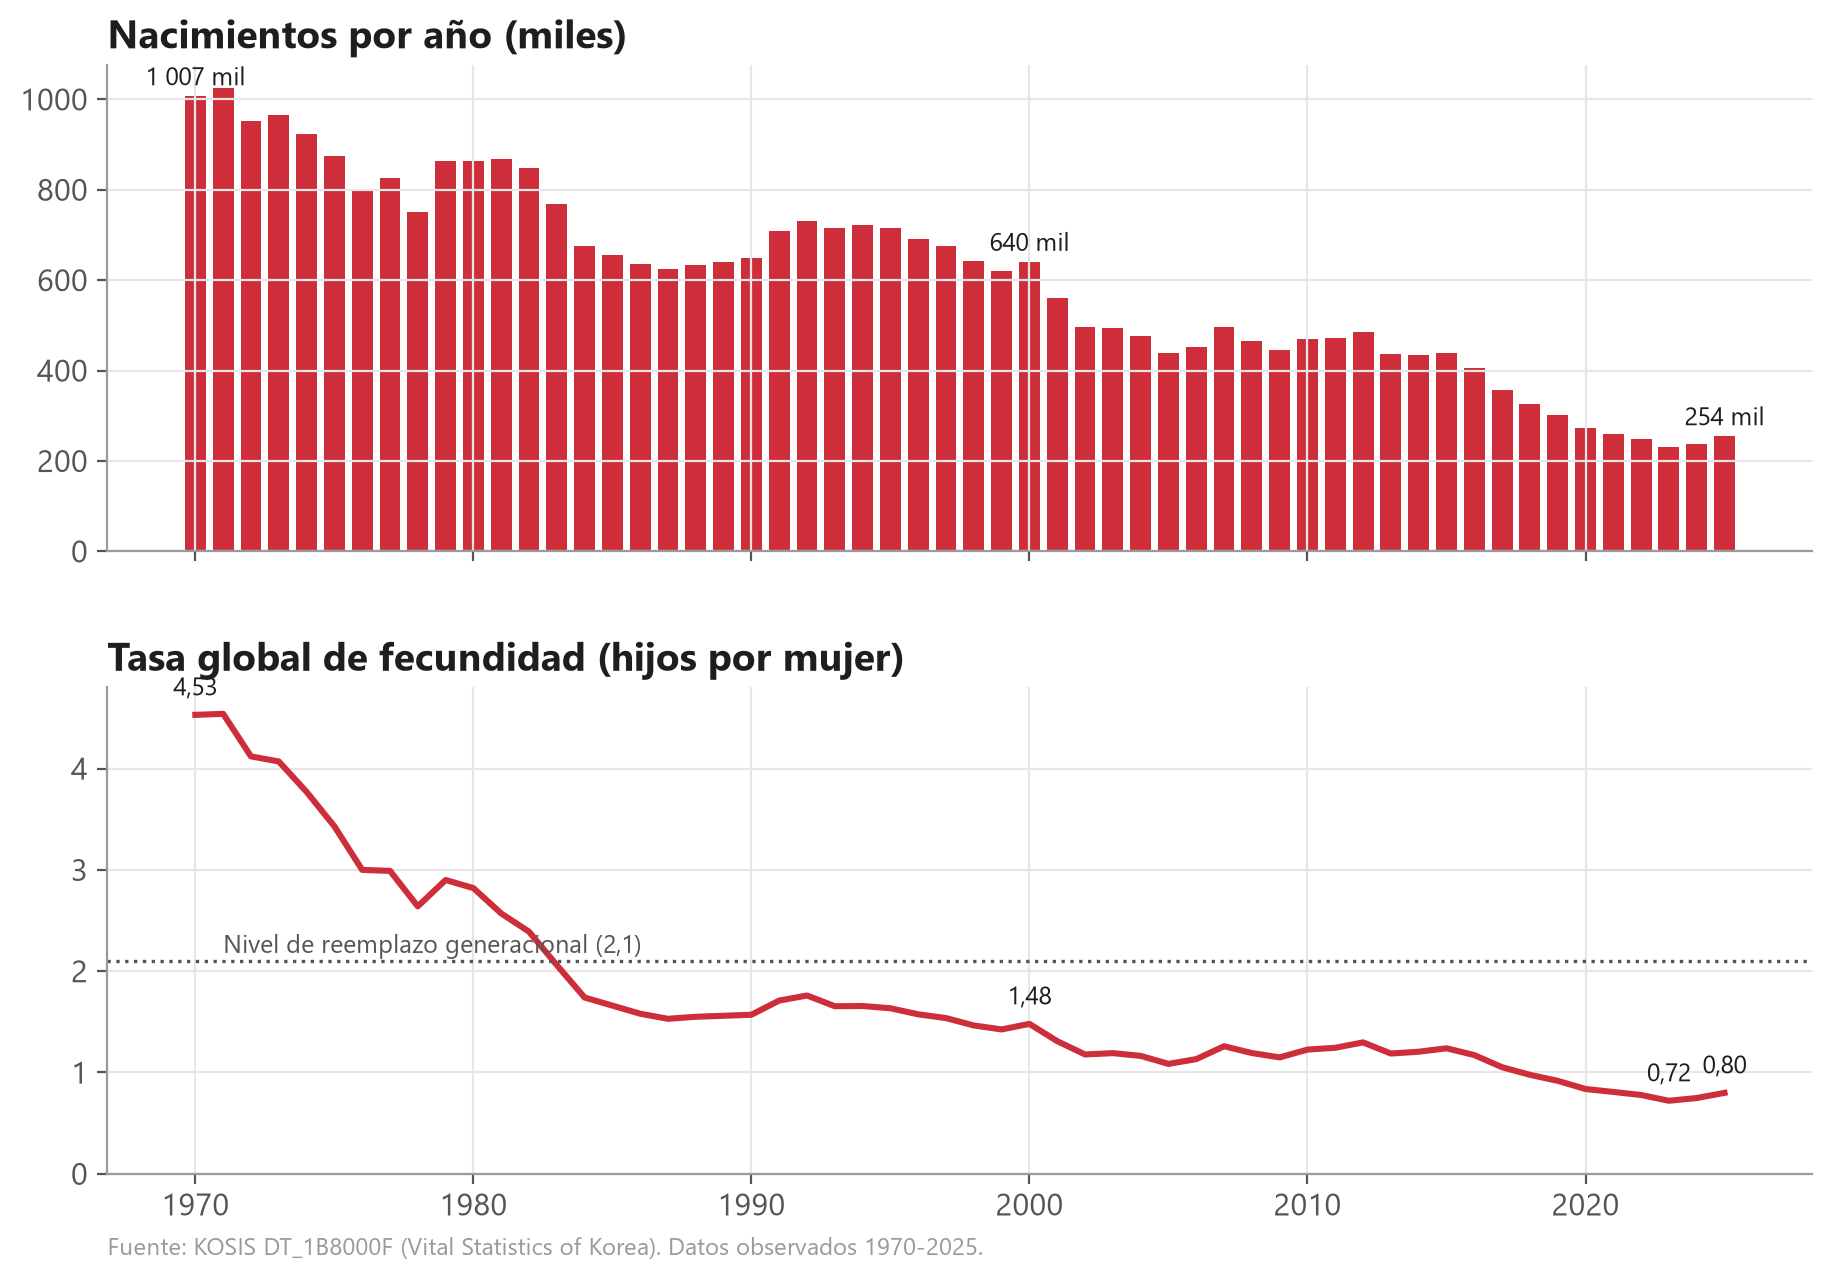

In [3]:
display(Image(str(F/'01_natalidad_fecundidad.png')))

## P2 · ¿Existe relación entre la caída de la natalidad y la población en edad de trabajar? *(estimado + proyección oficial)*

                        nacimientos_t_menos_17  poblacion_15_19_t  poblacion_15_64_t
nacimientos_t_menos_17                   1.000              0.955             -0.409
poblacion_15_19_t                        0.955              1.000             -0.506
poblacion_15_64_t                       -0.409             -0.506              1.000


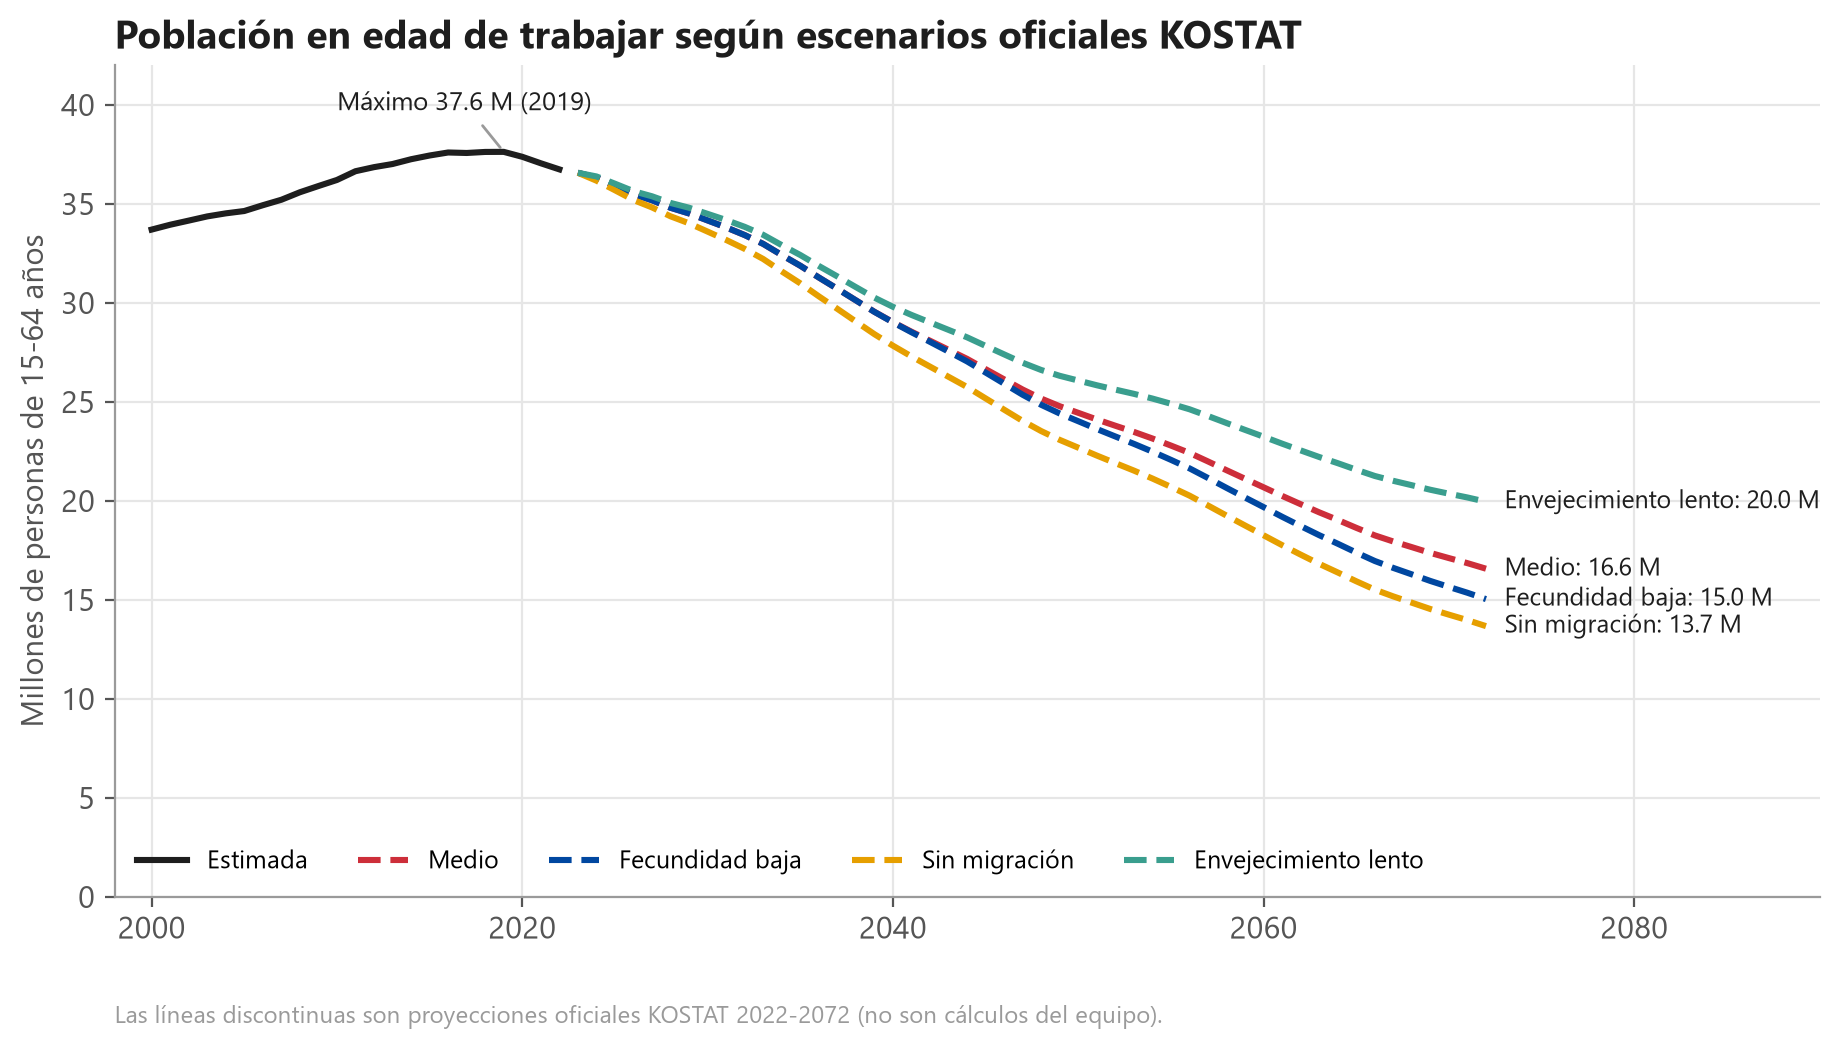

In [4]:
nac = h[(h.cod_indicador=='NACIMIENTOS')&(h.cod_territorio=='00')&(h.cod_sexo=='T')].set_index('anio').valor
p1564 = h[(h.cod_indicador=='POBLACION')&(h.cod_territorio=='00')&(h.cod_edad=='15-64')&(h.cod_sexo=='T')].set_index('anio').valor
p1519 = h[(h.cod_indicador=='POBLACION')&(h.cod_territorio=='00')&(h.cod_edad=='15-19')&(h.cod_sexo=='T')].set_index('anio').valor
# quienes nacen en t entran a la edad de trabajar entre t+15 y t+19: correlación con rezago de 17 años (punto medio)
rez = pd.DataFrame({'nacimientos_t_menos_17': nac.reindex(p1519.index - 17).values,
                    'poblacion_15_19_t': p1519.values, 'poblacion_15_64_t': p1564.reindex(p1519.index).values},
                   index=p1519.index).dropna()
print(rez.corr().round(3)); display(Image(str(F/'05_poblacion_edad_trabajar.png')))

Los nacimientos de hace 15 años determinan casi por completo la población que hoy entra a la edad laboral (15-19). La población 15-64 alcanzó su máximo en 2019 y, según **todas** las variantes oficiales de KOSTAT, cae en las próximas décadas.

## P3 · ¿Cómo cambia la proporción de adultos mayores y la dependencia? *(estimado / proyección / cálculo)*

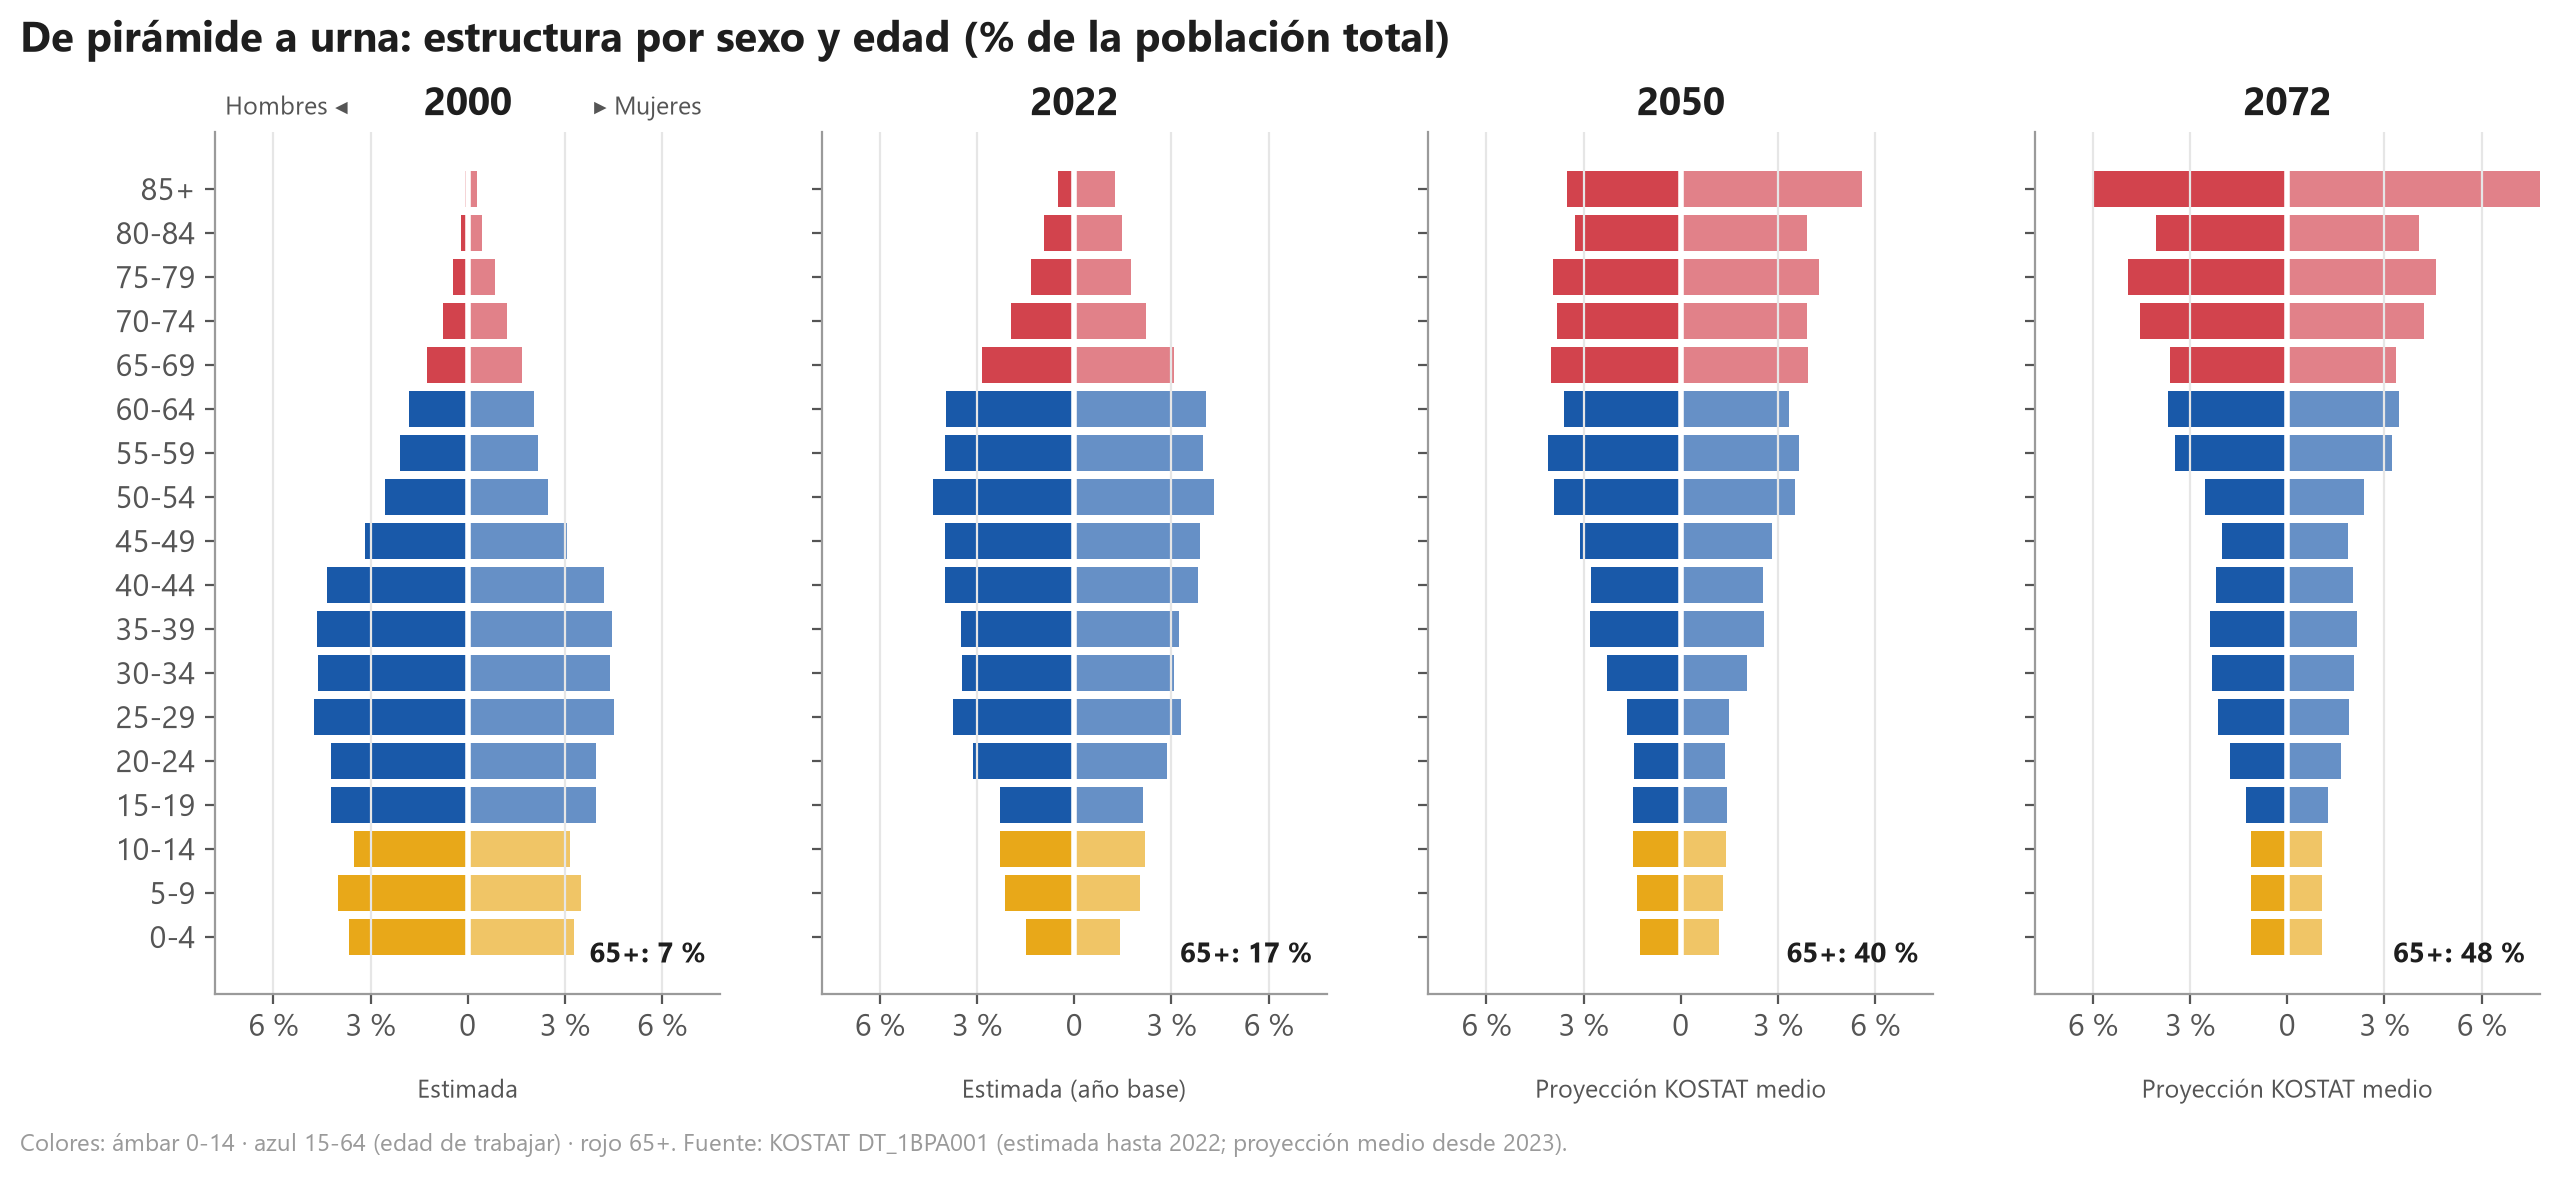

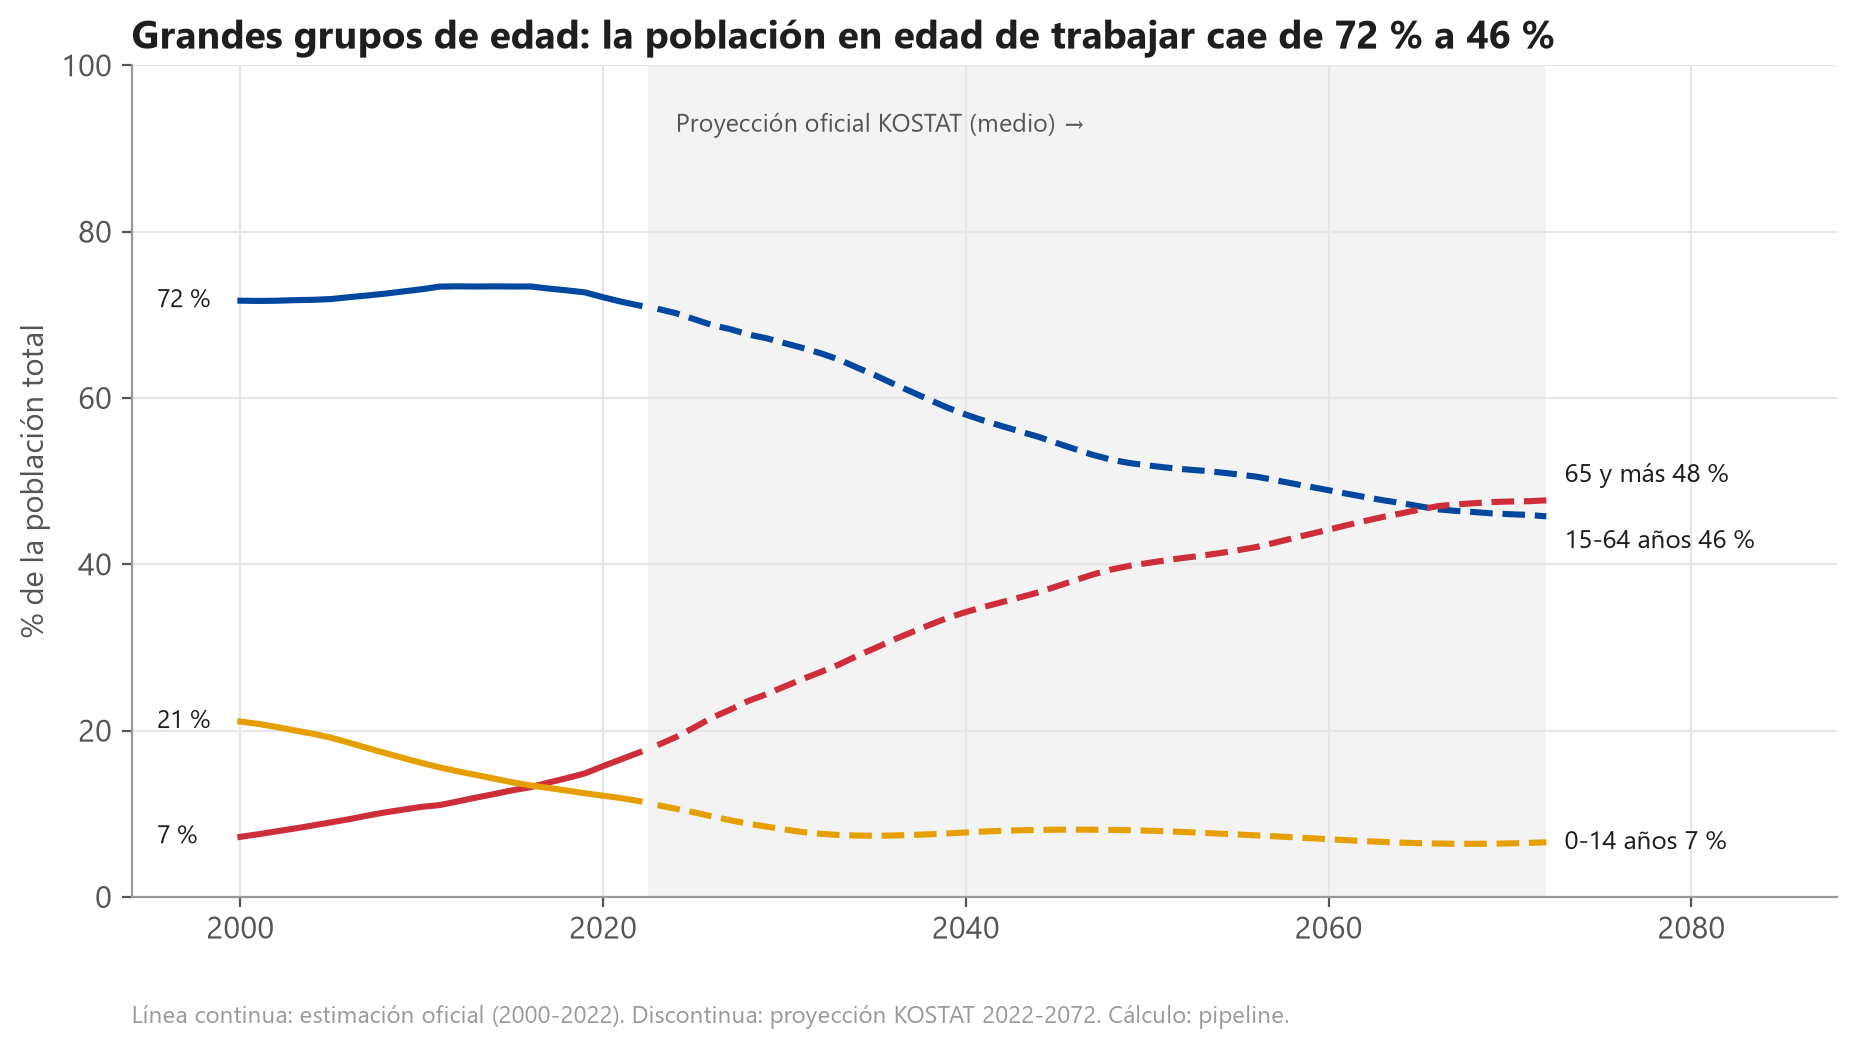

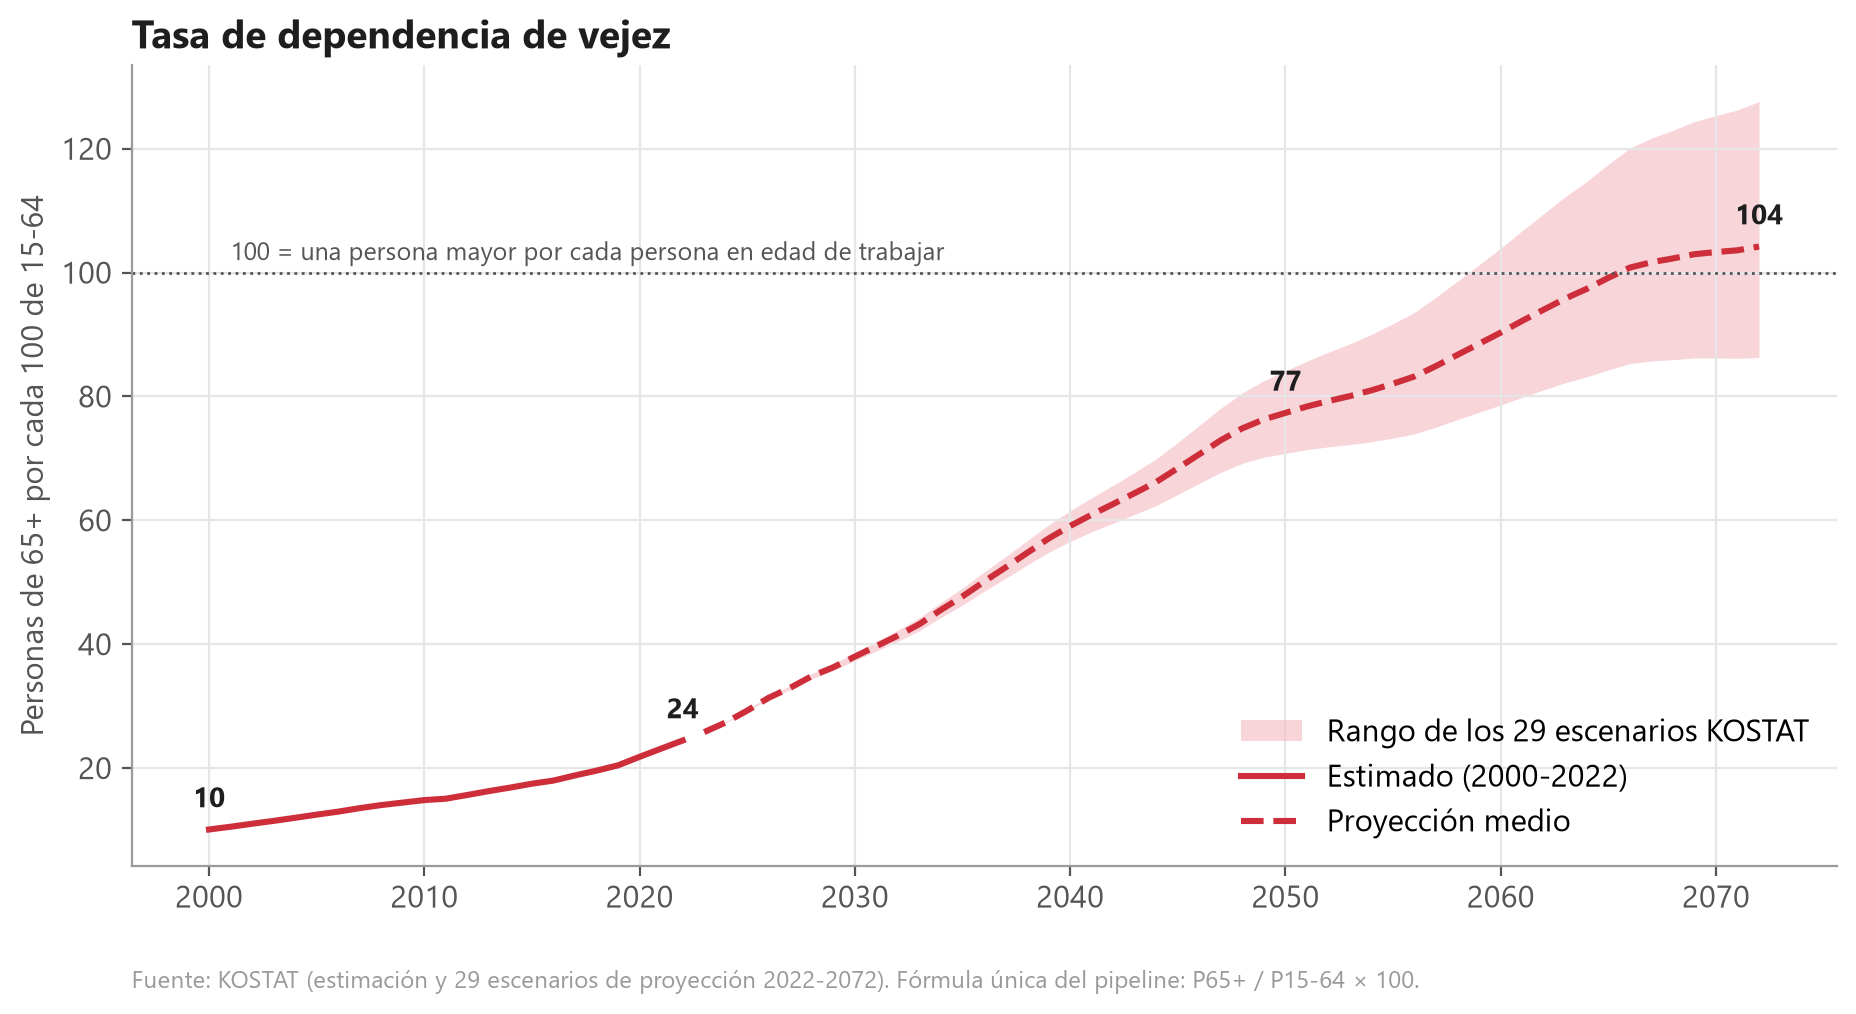

In [5]:
display(Image(str(F/'02_piramides_poblacion.png'))); display(Image(str(F/'03_estructura_edad.png'))); display(Image(str(F/'04_dependencia_vejez.png')))

## P4 · ¿Qué tendencias presenta la fuerza laboral frente al envejecimiento? *(observado)*

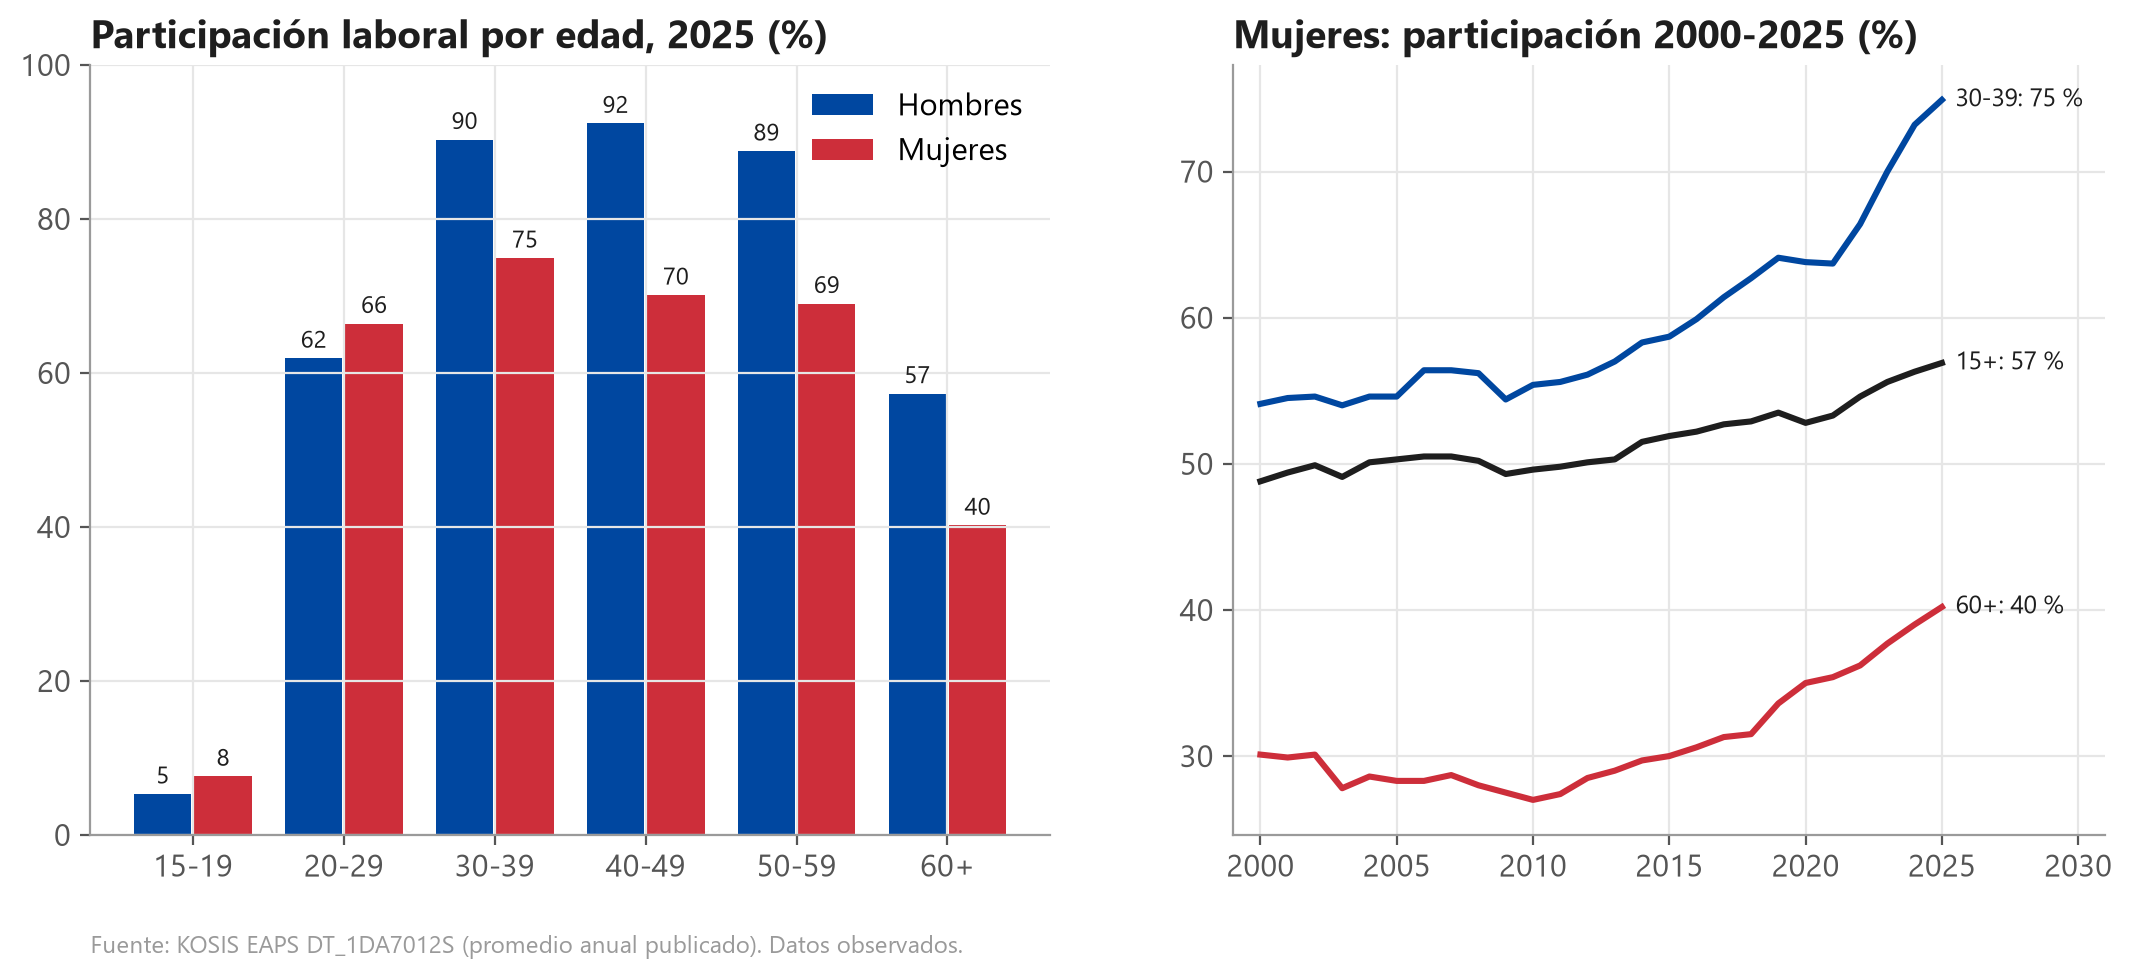

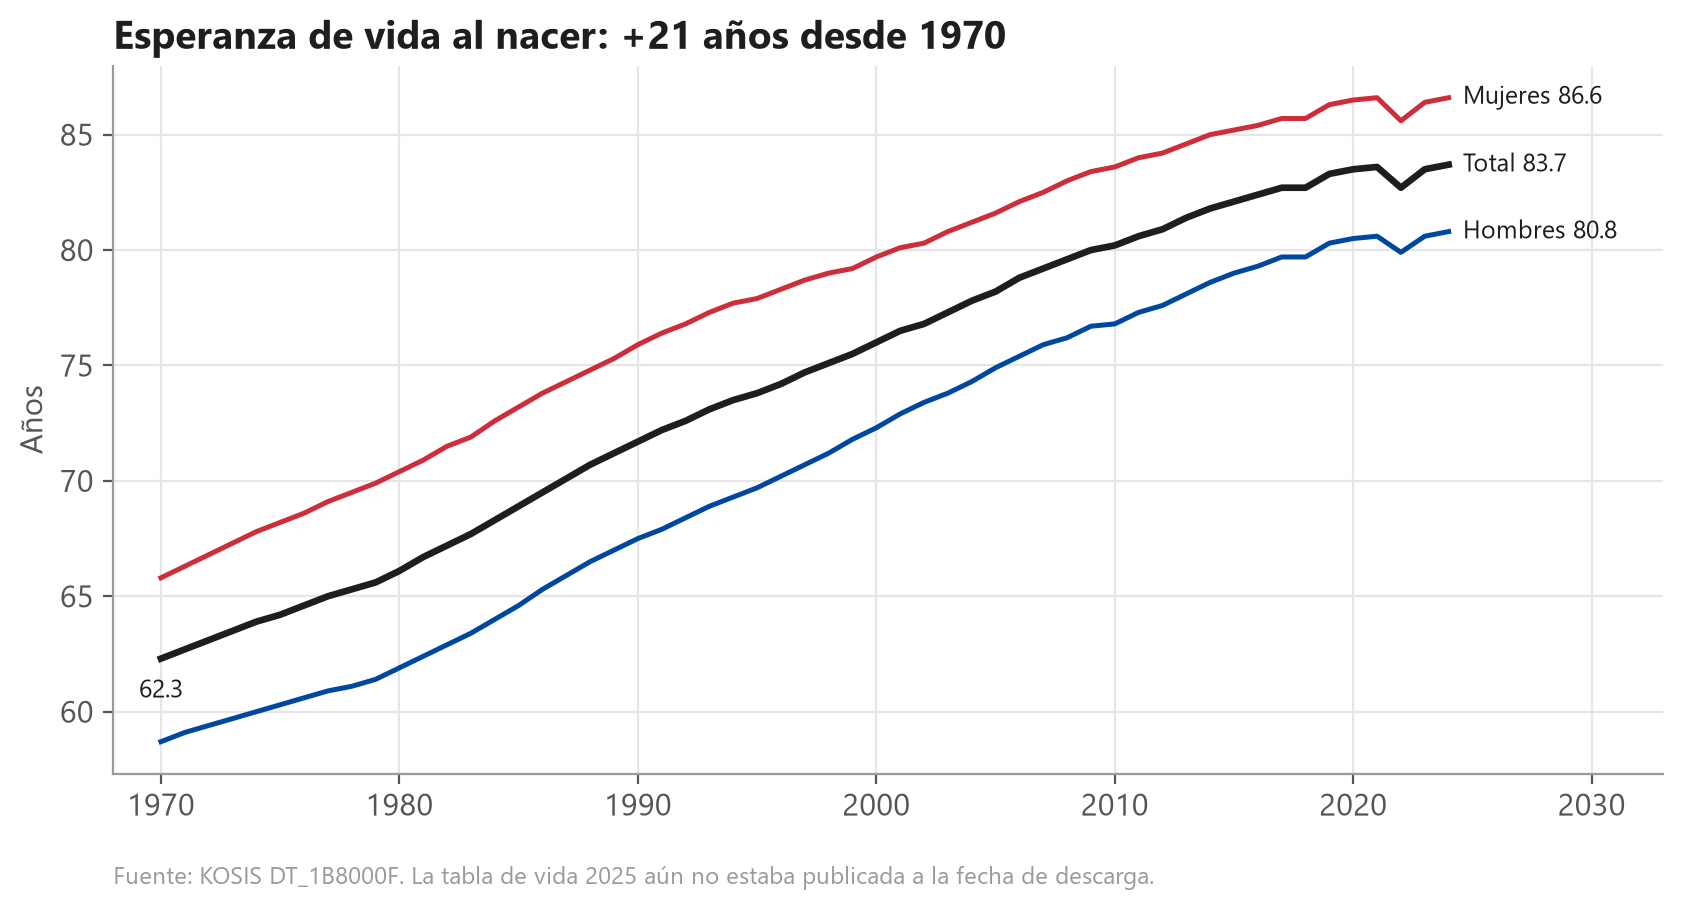

In [6]:
display(Image(str(F/'07_participacion_sexo_edad.png'))); display(Image(str(F/'12_esperanza_vida.png')))

## P5 · ¿Qué regiones tienen mayor riesgo demográfico? *(inferencia propia)*

,ranking_riesgo,nombre_es,nivel_riesgo,indice_riesgo,tfr,prop_65mas,dep_vejez,tasa_participacion,var_pob_15_64_2052_pct
1,1,Busan,Alto,0.98,0.74,24.46,36.93,60.0,-43.91
2,2,Daegu,Alto,0.58,0.81,21.16,30.84,59.9,-44.4
14,3,Gyeongsangbuk-do,Alto,0.52,0.93,26.12,40.46,66.5,-42.34
12,4,Jeonbuk,Alto,0.51,0.85,25.37,39.0,65.1,-40.93
15,5,Gyeongsangnam-do,Alto,0.4,0.88,22.17,32.97,64.6,-45.4
9,6,Gangwon,Alto,0.38,0.91,25.67,39.56,66.1,-33.08
13,7,Jeollanam-do,Medio,0.34,1.09,27.37,43.61,67.6,-39.98
0,8,Seúl,Medio,0.27,0.63,19.86,27.67,63.7,-34.56
6,9,Ulsan,Medio,0.21,0.92,17.83,25.18,61.3,-47.48
4,10,Gwangju,Medio,-0.05,0.76,17.95,25.31,62.9,-39.59


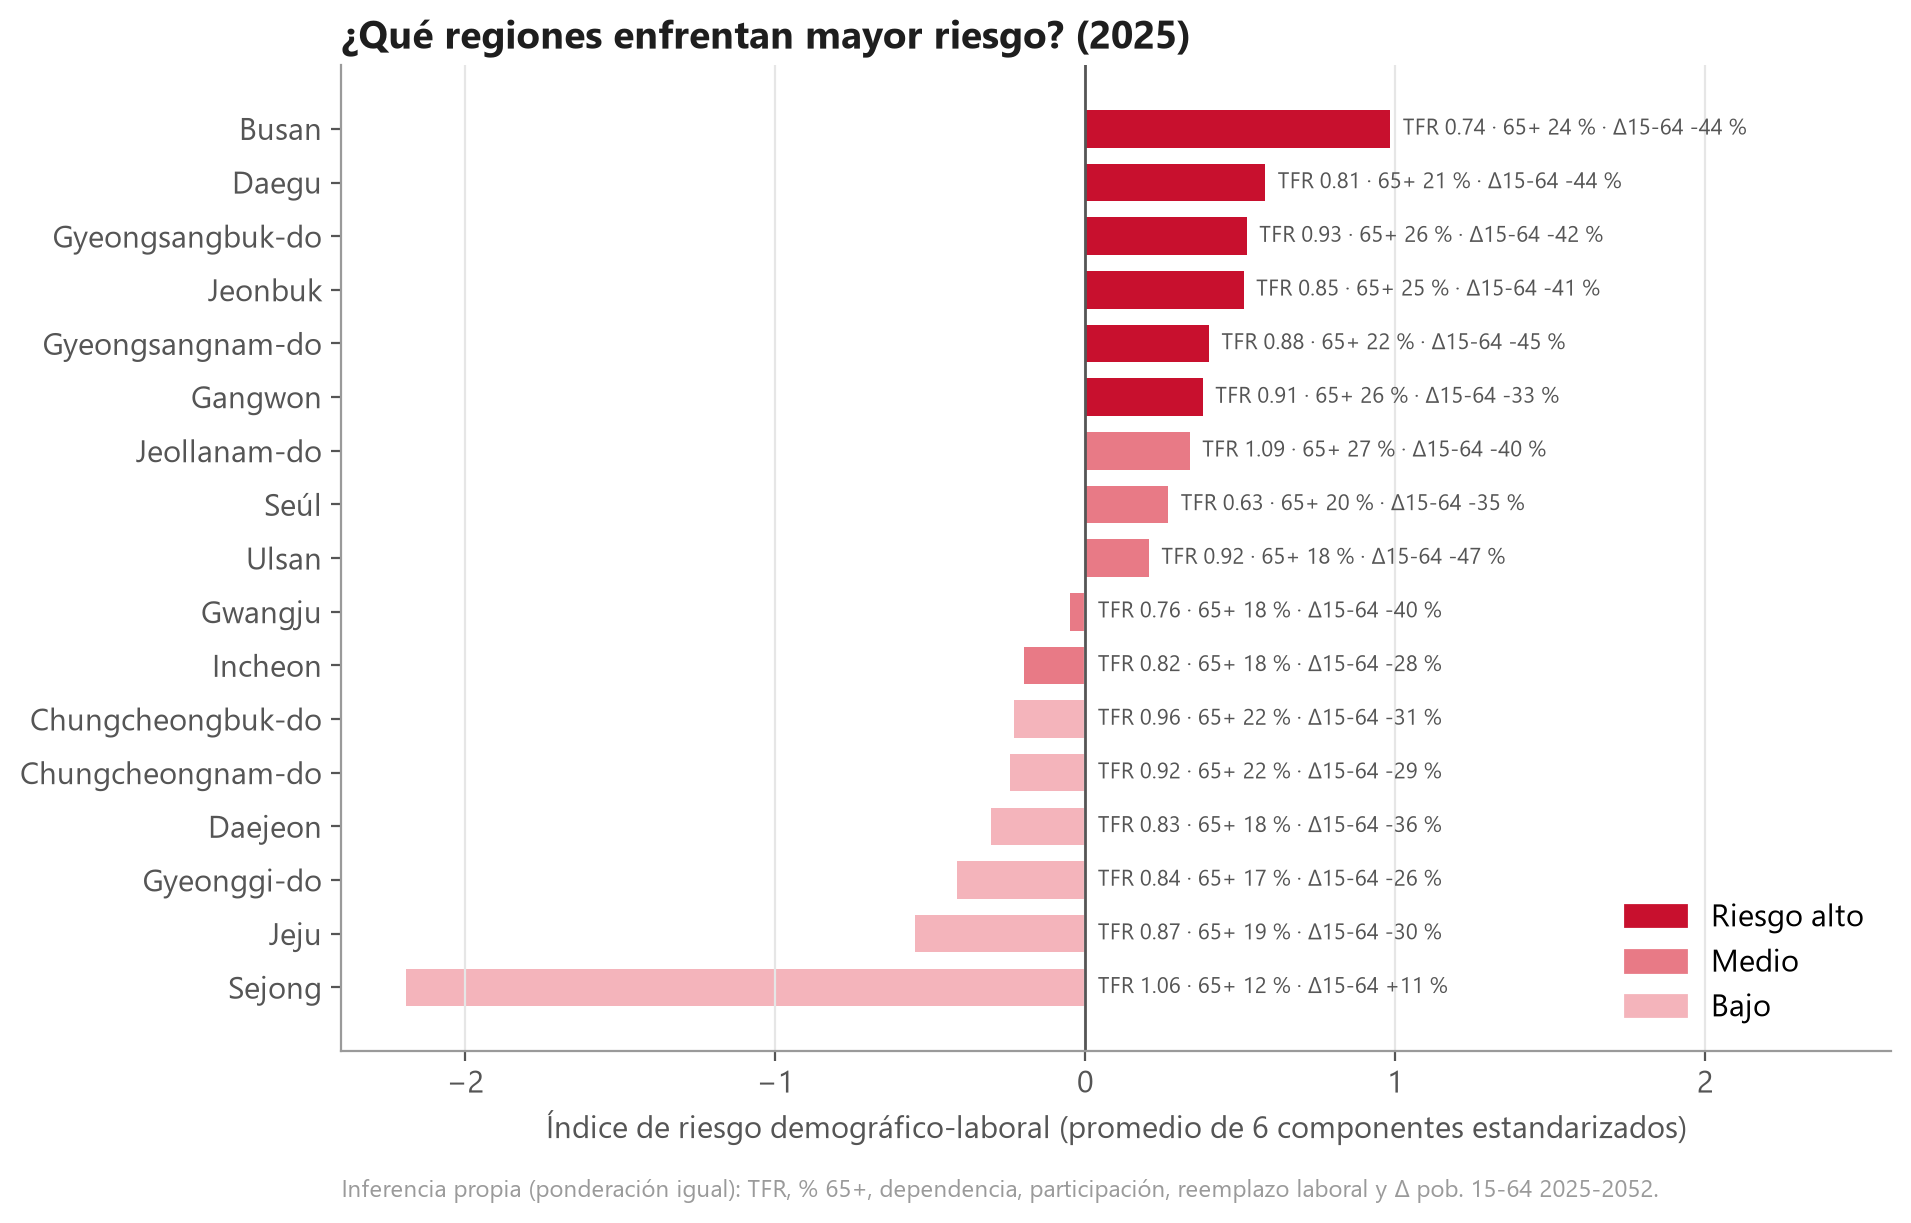

In [7]:
r = leer('fact_riesgo_regional').merge(leer('dim_territorio')[['cod_territorio','nombre_es']])
display(r.sort_values('ranking_riesgo')[['ranking_riesgo','nombre_es','nivel_riesgo','indice_riesgo','tfr','prop_65mas','dep_vejez','tasa_participacion','var_pob_15_64_2052_pct']].round(2))
display(Image(str(F/'08_riesgo_regional.png')))

## P6a · Población en edad de trabajar según proyecciones oficiales *(proyección oficial)*  
## P6b · Fuerza laboral potencial bajo supuestos *(escenario propio — no es pronóstico)*

anio                                        2025   2035   2050   2072
cod_escenario         cod_supuesto                                   
medio                 A_constante          29.61  29.26  26.14  19.64
                      B_tendencia          29.61  31.13  28.15  21.37
                      C_convergencia_ocde  29.61  29.28  26.12  19.65
                      D_brecha_genero      29.61   30.0  27.92  20.98
fecundidad_baja       A_constante          29.61  29.26  26.02  18.65
                      B_tendencia          29.61  31.13  28.04  20.36
                      C_convergencia_ocde  29.61  29.28   26.0  18.64
                      D_brecha_genero      29.61   30.0   27.8  19.95
fecundidad_alta       A_constante          29.61  29.26  26.29  20.64
                      B_tendencia          29.61  31.13   28.3  22.38
                      C_convergencia_ocde  29.61  29.28  26.27  20.68
                      D_brecha_genero      29.61   30.0  28.07  22.02
migracion_cero        A_constante          29.47  28.64  24.77  17.28
                      B_tendencia          29.47   30.5  26.75   18.9
                      C_convergencia_ocde  29.47  28.66  24.72  17.28
                      D_brecha_genero      29.47  29.37  26.49   18.5
migracion_alta        A_constante          29.69  29.74  27.16  21.33
                      B_tendencia          29.69  31.63  29.23  23.17
                      C_convergencia_ocde  29.69  29.76  27.15  21.35
                      D_brecha_genero      29.69  30.49  29.01  22.78
envejecimiento_rapido A_constante          29.54  28.93  25.38  17.45
                      B_tendencia          29.54  30.81  27.41  19.12
                      C_convergencia_ocde  29.54  28.96  25.35  17.44
                      D_brecha_genero      29.54  29.67  27.13   18.7

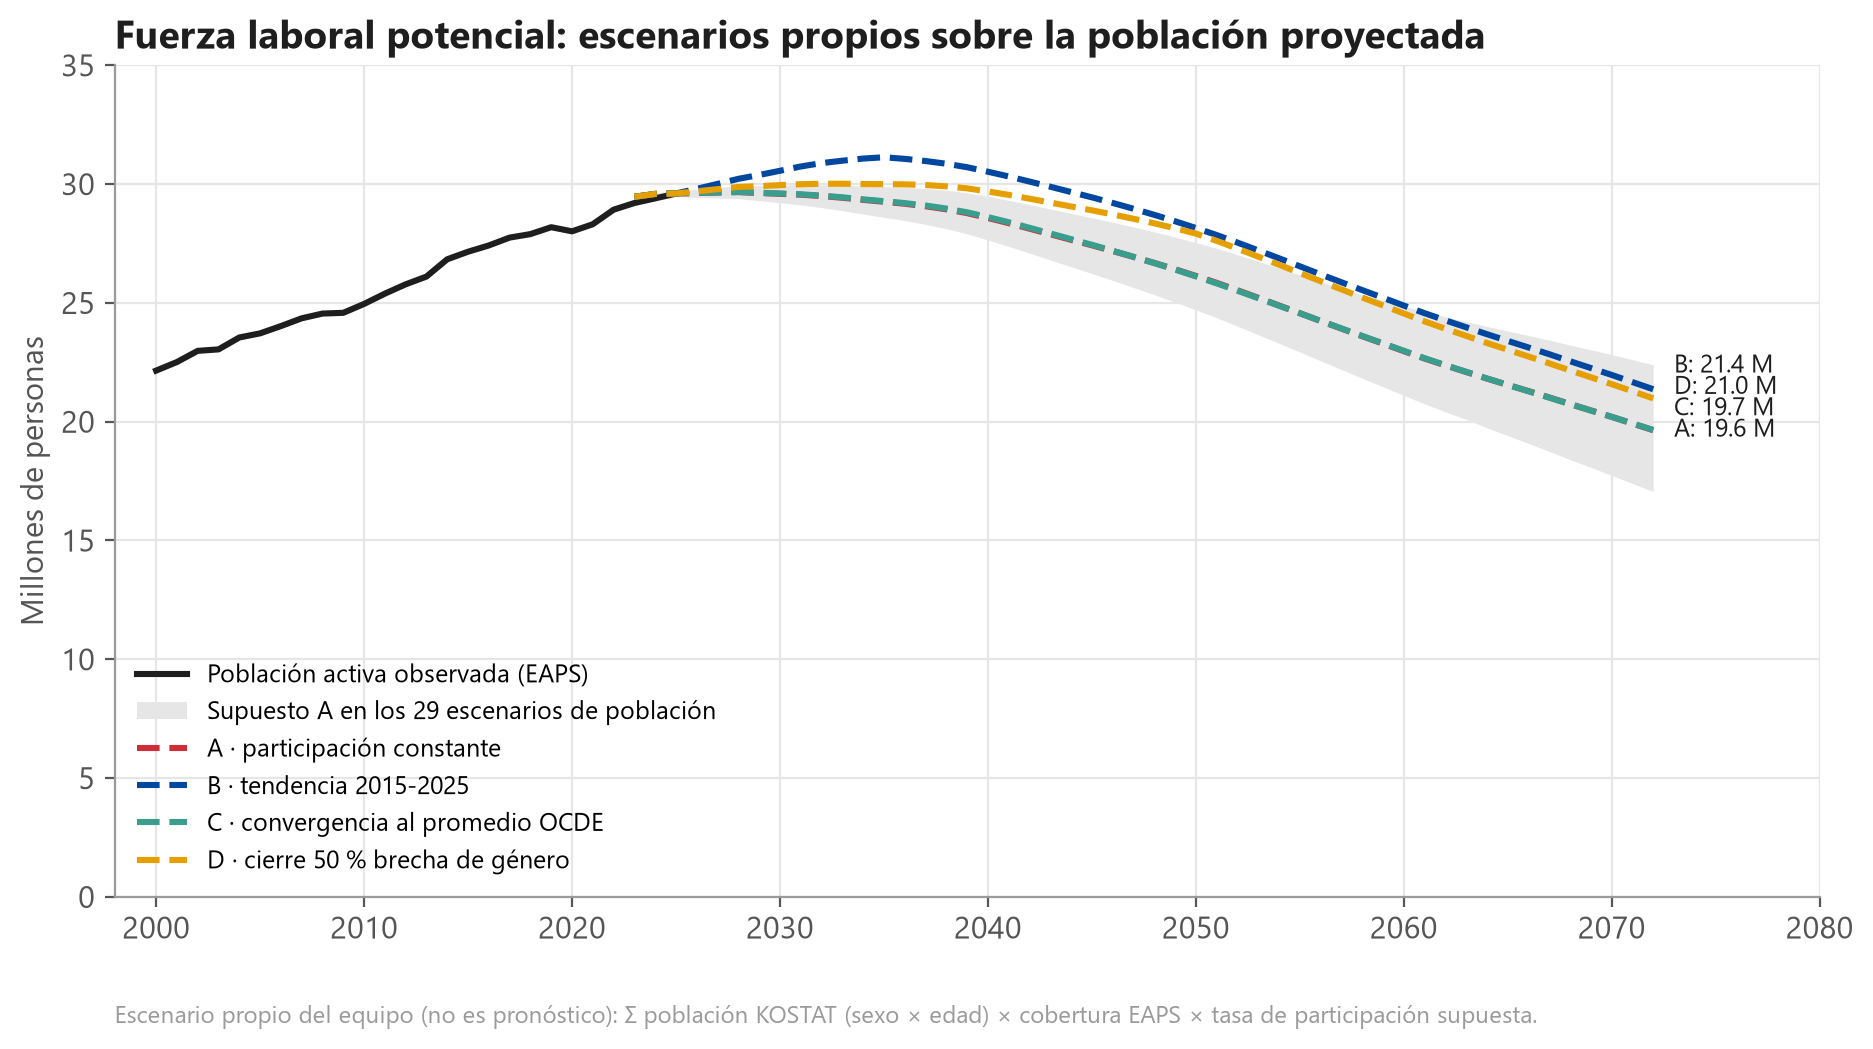

In [8]:
t = fl.groupby(['cod_escenario','cod_supuesto','anio']).fuerza_laboral_potencial.sum().unstack('anio')[[2025,2035,2050,2072]]/1e6
display(t.loc[['medio','fecundidad_baja','fecundidad_alta','migracion_cero','migracion_alta','envejecimiento_rapido']].round(2))
display(Image(str(F/'06_fuerza_laboral_escenarios.png')))

Supuestos: **A** constante · **B** tendencia 2015-2025 · **C** convergencia al promedio OCDE · **D** cierre del 50 % de la brecha de género (C y D, aportes del Avance 2 y del repositorio de Miguel). Incluso con B o D la fuerza laboral potencial cae después de 2035: el efecto demográfico domina. La migración es la palanca con mayor efecto en el corto plazo.

**Sensibilidad:** cada fila cambia un parámetro de un supuesto y recalcula la variación 2025 → 2050 (escenario medio).

In [9]:
s = pd.read_parquet(GOLD/'fact_escenarios_sensibilidad.parquet')
display(s[['cod_supuesto','variante','var_2050_pct','var_2072_pct']].round(1))

,cod_supuesto,variante,var_2050_pct,var_2072_pct
0,A_constante,base,-11.7,-33.7
1,B_tendencia,base,-4.9,-27.8
2,C_convergencia_ocde,base,-11.8,-33.6
3,D_brecha_genero,base,-5.7,-29.1
4,B_tendencia,tope_pp = 5,-7.6,-30.0
5,B_tendencia,tope_pp = 15,-4.4,-27.4
6,B_tendencia,horizonte_tendencia = 2030,-8.0,-30.5
7,B_tendencia,horizonte_tendencia = 2040,-3.8,-26.9
8,C_convergencia_ocde,anio_convergencia = 2040,-11.8,-33.6
9,C_convergencia_ocde,anio_convergencia = 2060,-11.8,-33.6


## P7 · Envejecimiento, empleo y productividad *(observado; asociación, no causalidad)*

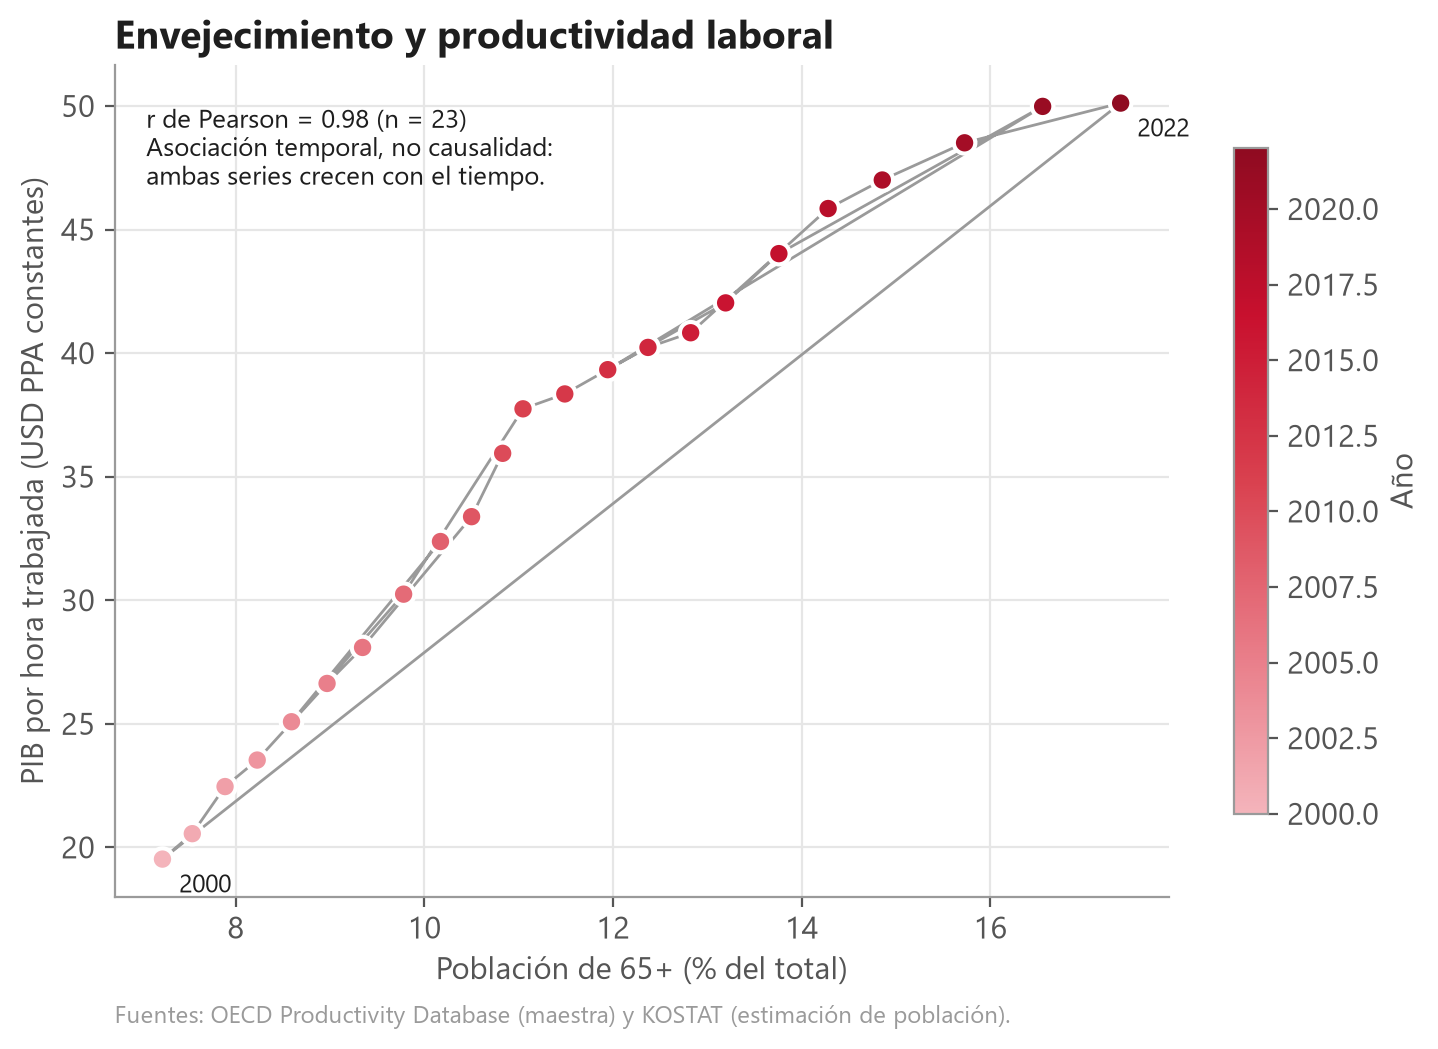

In [10]:
display(Image(str(F/'10_productividad_envejecimiento.png')))

## P8 · Señales tempranas de escasez laboral *(cálculo sobre estimado + proyección)*

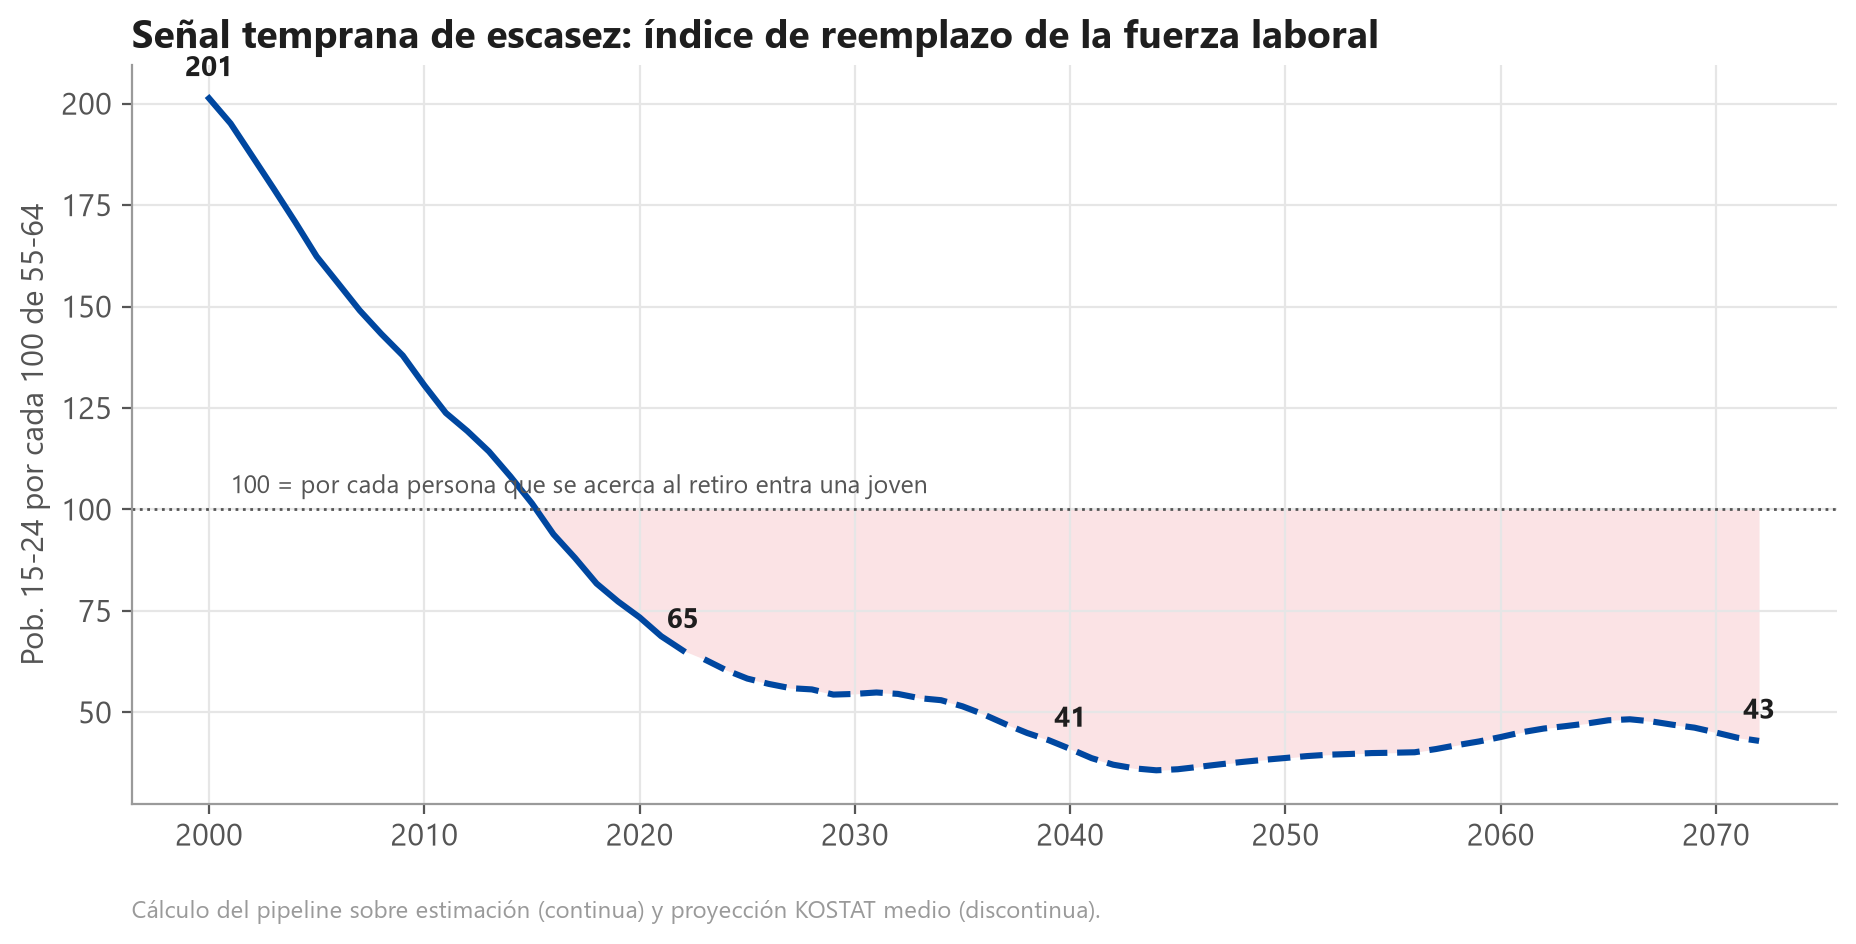

In [11]:
display(Image(str(F/'11_reemplazo_laboral.png')))

## P9 · Comparación con la OCDE *(observado, World Bank)*

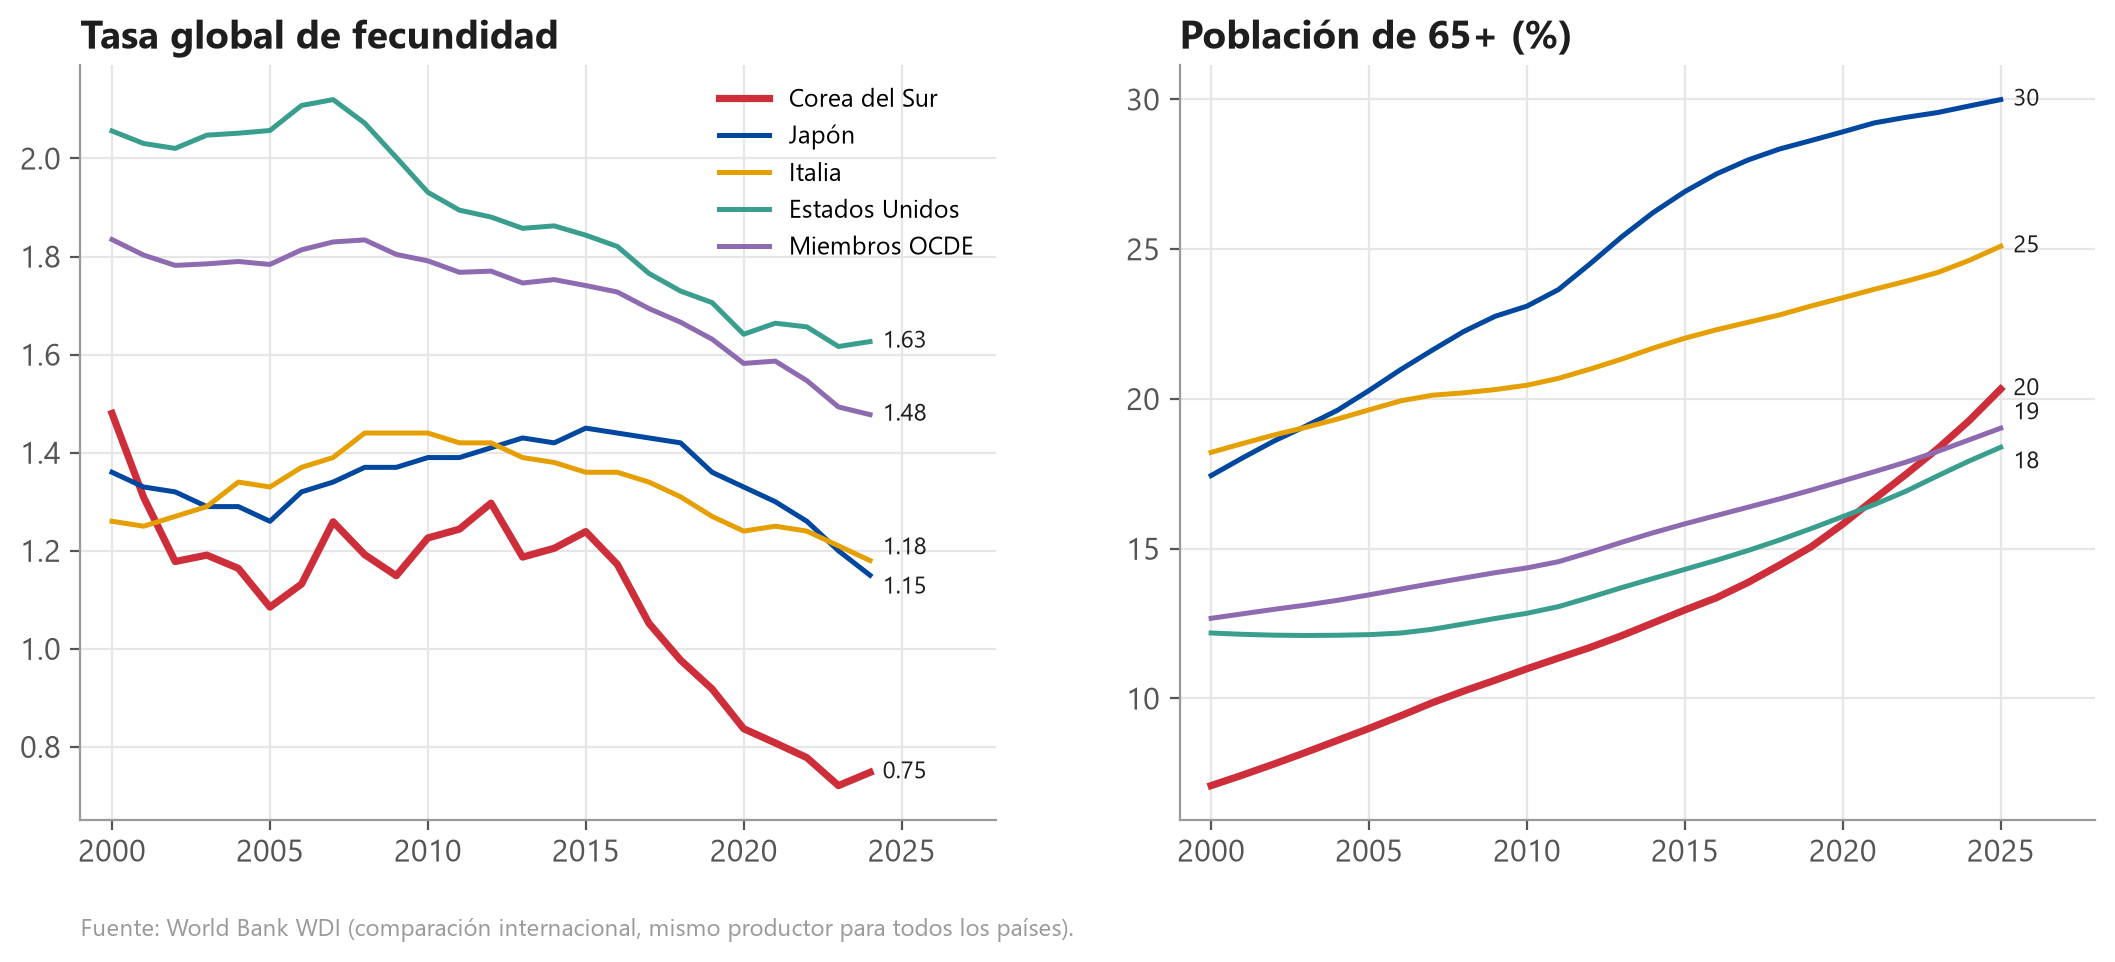

In [12]:
display(Image(str(F/'09_comparacion_internacional.png')))

## P10 · Información para política pública
- **Natalidad:** aun si la TFR se recuperara (escenario fecundidad alta), los nacidos después de 2025 no entran a la
  edad laboral antes de 2040: el efecto sobre la fuerza laboral de 2050 es pequeño (≈ 1,3 pp en la población 15-64).
- **Participación:** el mayor margen está en mujeres (brecha de 16 pp) y en personas de 60+ (supuestos B y D).
- **Migración:** pasar de migración cero a alta cambia la población 15-64 de 2050 en ≈ 8 pp.
- **Territorio:** Busan, Daegu y Gyeongsang concentran el mayor riesgo; Sejong y Gyeonggi el menor.

**Robustez del índice regional:** veces que cada si-do queda en el top 5 con los 7 esquemas de ponderación.

In [13]:
r = pd.read_parquet(GOLD/'fact_riesgo_sensibilidad.parquet').merge(pd.read_parquet(GOLD/'dim_territorio.parquet')[['cod_territorio','nombre_es']])
display(r[r.en_top5].groupby('nombre_es').esquema.nunique().sort_values(ascending=False).rename('esquemas en el top 5'))

nombre_es
Busan               7
Gyeongsangbuk-do    7
Jeonbuk             6
Daegu               5
Gangwon             3
Gyeongsangnam-do    3
Jeollanam-do        3
Seúl                1
Ulsan               1
Name: esquemas en el top 5, dtype: int64